# Wk 2 Exercises

This notebook contains **five exercises** on Matplotlib figures, axes, spines, ticks, GridSpec, and legend anchoring. Complete the code cells and run them to produce the requested figures.
-  Note: I found myself thinking in a state based way at first and had a very hard time
-  I had to remind myself that with and object oriented system their are nested lists that persist and can be iterated

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [89]:
# Reproducible randomness for the irregular signal
np.random.seed(2026)

**1. (10 pts). Manual Axes Positioning and Bounds. Tasks:**
- Create a figure `fig` sized height= 4, width= 4.
- Add an axes at `[0.15, 0.15, 0.75, 0.75]`
- Plot (x, sin(x))
- Remove the top and right spine.
- Change the bounds of the left and bottom spine to (-0.5, 0.5) and (3,7) respectively.
- Label your axes and provide a title.




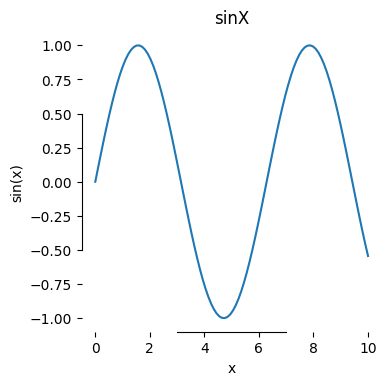

In [90]:
fig = plt.figure(figsize=(4, 4))

# Data
x = np.linspace(0, 10, 100)

# Add an axes: [left, bottom, width, height] in figure coordinates (0 to 1)
ax = fig.add_axes([0.15, 0.15 ,0.75, 0.75])

# Plot some data
ax.plot(x, np.sin(x))
ax.set_xlabel('x')#x labs
ax.set_ylabel('sin(x)')#y labs
ax.set_title('sinX', fontsize=12)

#getting rid of spines
ax.spines['right'].set_visible(False)# right 
ax.spines['top'].set_visible(False)# top

#repositioning spines
ax.spines['left'].set_bounds(-0.5, 0.5)
ax.spines['bottom'].set_bounds(3, 7)

plt.show()#what does it mean that this removes the return?

**2. (20 pts) Create the following figure:**
- Figure size is 8x4.
- Contains two Axes:
  - Axes1:
      - Anchored at (0.05, 0.05) and spans 90% width and height of figure.
      - Data1. x: x1, y: y1
      - Line chart
      - Label each x and y axis
      - title
  - Axes2:
      - Anchored at (0.8, 0.12) and spans 15% width and height of figure.
      - Bar chart.
      - Data2. x: cats, y: vals
      - No spines
      - No x or y ticks
      - y tickslabels: None
      - x ticklabels: Bar Name 
      - title: 'Inset'    

*Hint*. To remove ticks and tickmarks use `ax.tick_params()`

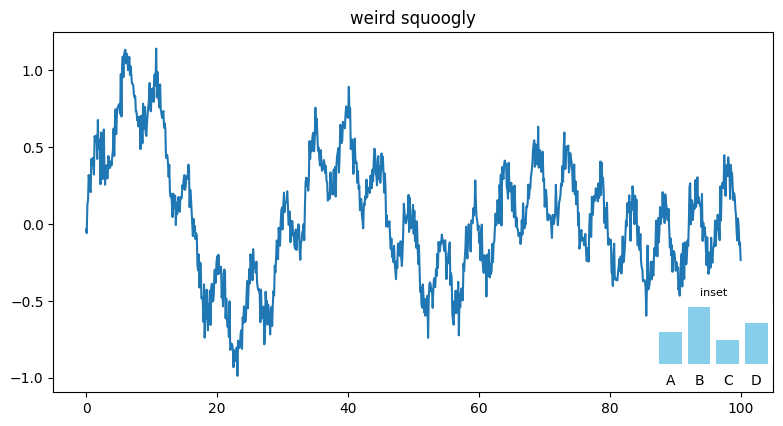

In [91]:
#importing ticker here and at the start
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt

# Data 1
x1 = np.linspace(0, 100, 1000)
y1 = np.sin(x1 / 5) * np.exp(-x1 / 50) + 0.25 * np.sin(x1 * 1.3) + 0.08 * np.random.randn(len(x1))

# Data 2
cats = ['A', 'B', 'C', 'D']
vals = [4, 7, 3, 5]

fig = plt.figure(figsize=(8, 4))
axes = []#establish axes as a list so I can add axes without them covering eachother

# Main plot
axes.append(fig.add_axes([0.05, 0.05, 0.9, 0.9]))#anchoring via 'add_axes' idk if theres another way
axes[0].plot(x1, y1)
axes[0].set_title("weird squoogly")

# Inset bar chart
axes.append(fig.add_axes([0.8, 0.12, 0.15, 0.15]))
axes[1].bar(cats, vals, color='skyblue')
axes[1].set_title("inset", fontsize=8)

# Clean inset appearance
#axes[1].xaxis.set_major_locator(ticker.NullLocator())#this was the only way I could figure out to make this 
#axes[1].yaxis.set_major_locator(ticker.NullLocator())
axes[1].tick_params(
    bottom=False, 
    left=False,
    labelbottom=True, 
    labelleft=False
)#using tick_params to hide tick and keep labels 

for spine in axes[1].spines.values():
    spine.set_visible(False)#using the a for loop to select 'spine' objects in the 'axes[1]' list

plt.show()



**3. (20 pts) Generate the following plot**
- Create a `2×2` grid with size 8x4.
- Plot four different functions (e.g., `sin`, `cos`, `sin(2x)`, `exp(-x/5)`) and titled each plot.
- Ensure only bottom row shows xtics and ticklabels and only left column shows y ticks and ticklabels.

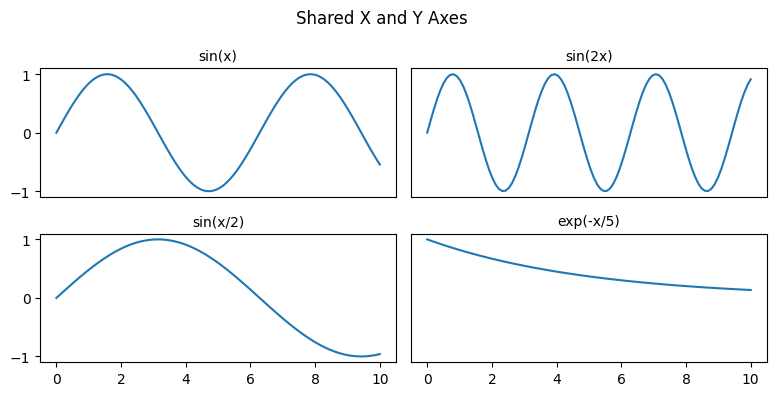

In [92]:
# Data
x = np.linspace(0, 10, 200)

# 2x2 plots sharex and sharey
fig, axes = plt.subplots(2,2, figsize=(8,4), sharex= True, sharey= True) #creates both figure and subplots

# Create Data
x = np.linspace(0, 10, 100)
data_sets = [
    (np.sin(x), 'sin(x)'),
    (np.sin(2*x), 'sin(2x)'),
    (np.sin(x/2), 'sin(x/2)'),
    (np.exp(-x/5), 'exp(-x/5)'),
]#creating a data list to iterate through
# Iterate through
for ax, (data, title) in zip(axes.flatten(), # Flatten the 2D array to 1D
                             data_sets):
    ax.plot(x, data)
    ax.set_title(title, size=10)

# Remove inner ticks
for ax in axes[0, :]:        # top row
    ax.tick_params(bottom=False)

for ax in axes[:, 1]:        # right column
    ax.tick_params(left=False)

fig.suptitle('Shared X and Y Axes', fontsize=12)
fig.tight_layout()

plt.show()

#does not show the x and y axis for all plots unless you use "sharex" and "sharey"
#this is important for if you want to compare data with different scales

**4. (30 pts).  Build a non-uniform layout using `GridSpec()` functionality. Your plot with have the following characteristics:**
- Figure will have four `Axes`:
  - On the first row, `Axes` 1 will span across all columns. This axes will plot $(x,sin(x))$
  - On the second row, `Axes` 2 will span across two columns. This axes will plot $(x,cos(x))$
  - On the second row, `Axes` 3 and 4 will only span across one column and one row. These axes will plot $(x,tan(\frac{x}{4}))$,$(x,exp(\frac{-x}{5}))$
- Each plot `Axes` will be titled.
- The will be a title for the entire figure.

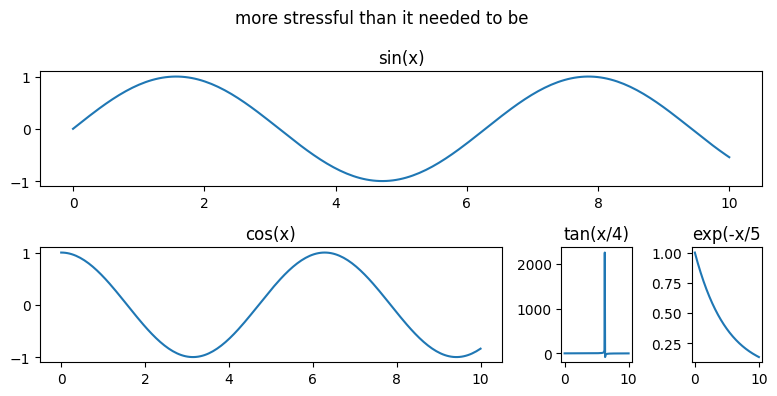

In [95]:
# Data
x = np.linspace(0, 10, 200)

fig = plt.figure(figsize=(8, 4))
fig.suptitle('more stressful than it needed to be')
gs = fig.add_gridspec(2, 6)# 2x2 grid

# Combine the first 2 axes in row 0 into one
ax1 = fig.add_subplot(gs[0, 0:6])
ax1.set_title('sin(x)')
ax1.plot(x, (np.sin(x)))
                      
#  in the bottom row
ax2 = fig.add_subplot(gs[1, 0:4])
ax2.set_title('cos(x)')
ax2.plot(x, (np.cos(x)))

#squished guys
ax3 = fig.add_subplot(gs[1, 4])
ax3.set_title('tan(x/4)')
ax3.plot(x, (np.tan(x/4)))

ax4 = fig.add_subplot(gs[1, 5])
ax4.set_title('exp(-x/5')
ax4.plot(x, (np.exp(-x/5)))


fig.tight_layout()
plt.show()

**5. (20 pts) Using the data provided. Generate a line chart such that:**
- X axis must have:
   - A maximum of 10 major tickmarks.
   - Each major ticklabels should have the following string format '%.0f'.
   - Minor tick marks will be set at 0.5 intervals
   - No minor labels
- Y axis must have:
  - A major tick mark at each 0.5 interval
  - A custom function formatter that shows two decimals and appends a unit string '{value:.2f} units'.
  - An automatic minor locator between major ticks.

```{note}
Whatever function you use with `FuncFormatter()` make sure that it receives at least two parameters: 
- one for the label you want to format
- one of the position which you can ignore for the purposes of your formatting.
```

In [ ]:
# Data
x = np.linspace(0, 10, 500)
y = np.sin(x) * (1.0 + 0.3 * np.cos(3 * x))